# Cross-Country Climate Comparison and Vulnerability Ranking
## Climate Challenge Week 0 — Task 3

### Objective
Compare climate trends across Ethiopia, Kenya, Nigeria, Tanzania, and Sudan to assess relative climate vulnerability and generate evidence-based insights relevant to COP32.

# 1. Data Loading and Dataset Integration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")

In [4]:
ethiopia["Country"]="Ethiopia"
kenya["Country"]="Kenya"
nigeria["Country"]="Nigeria"
tanzania["Country"]="Tanzania"
sudan["Country"]="Sudan"

In [5]:
df = pd.concat(
    [ethiopia, kenya, nigeria, tanzania, sudan],
    ignore_index=True
)

In [6]:
df["Country"].value_counts()

Country
Ethiopia    4108
Kenya       4108
Nigeria     4108
Tanzania    4108
Sudan       4108
Name: count, dtype: int64

# 2. Temperature Trend Comparison

In [7]:
monthly_temp = (
    df.groupby(["Country","Month"])["T2M"]
      .mean()
      .reset_index()
)

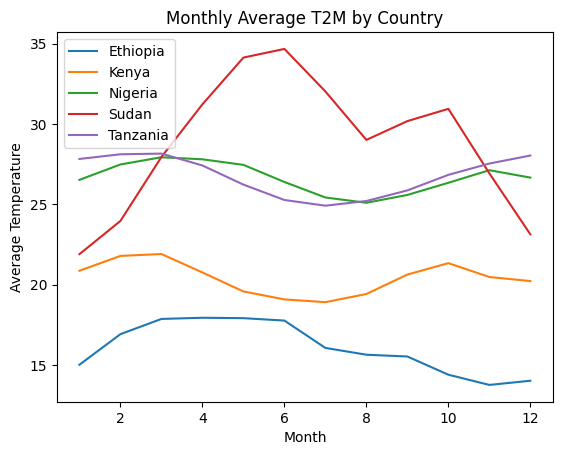

In [8]:
for country in monthly_temp["Country"].unique():
    subset = monthly_temp[
        monthly_temp["Country"]==country
    ]
    
    plt.plot(
        subset["Month"],
        subset["T2M"],
        label=country
    )

plt.legend()
plt.xlabel("Month")
plt.ylabel("Average Temperature")
plt.title("Monthly Average T2M by Country")
plt.show()

In [9]:
df.groupby("Country")["T2M"].agg(
    ["mean","median","std"]
)

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


Temperature differences across countries suggest variation in baseline warming levels and climate variability. Mean and standard deviation provide an initial basis for comparing relative heat exposure.

# 3. Precipitation Variability Comparison

In [10]:
df.groupby("Country")["PRECTOTCORR"].agg(
    ["mean","median","std"]
)

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


C:\Users\nbe\AppData\Local\Temp\ipykernel_1340\1709856950.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=countries)


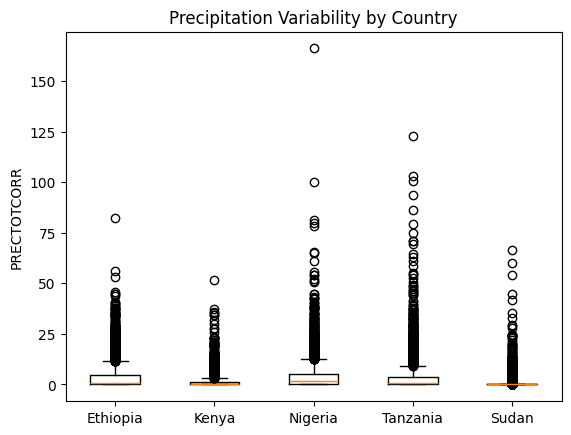

In [11]:
countries = df["Country"].unique()

data = [
    df[df["Country"]==c]["PRECTOTCORR"]
    for c in countries
]

plt.boxplot(data, labels=countries)

plt.title("Precipitation Variability by Country")
plt.ylabel("PRECTOTCORR")
plt.show()

Differences in spread and outliers suggest variation in precipitation stability across countries. Wider distributions may indicate greater rainfall volatility and climate risk.

# 4. Extreme Event Frequency Analysis

In [ ]:
extreme_heat = (
df[df["T2M_MAX"] > 35]
.groupby("Country")
.size()

)

extreme_heat

Country
Sudan    2694
dtype: int64

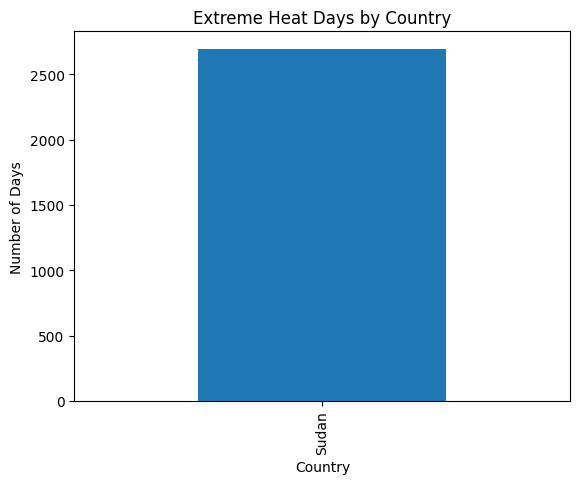

In [13]:
extreme_heat.plot(kind="bar")

plt.title("Extreme Heat Days by Country")
plt.ylabel("Number of Days")
plt.show()

In [14]:
dry_days = (
df[df["PRECTOTCORR"] < 1]
.groupby("Country")
.size()
)

dry_days

Country
Ethiopia    2161
Kenya       2831
Nigeria     1595
Sudan       3696
Tanzania    2303
dtype: int64

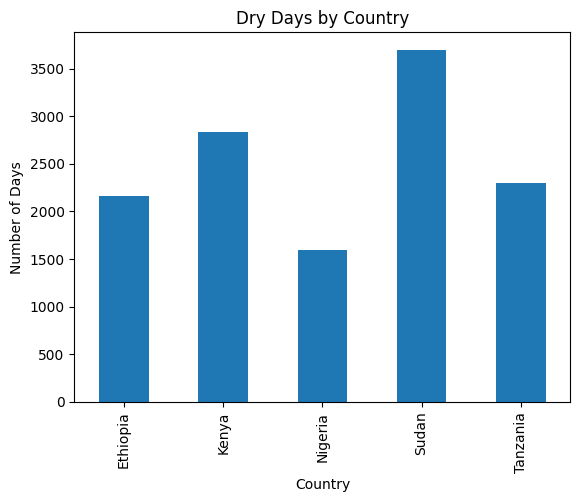

In [15]:
dry_days.plot(kind="bar")

plt.title("Dry Days by Country")
plt.ylabel("Number of Days")
plt.show()

Extreme heat frequency and dry-day counts provide indicators of climate stress exposure. Higher counts may suggest elevated vulnerability to heat and drought-related impacts.

# 5. Statistical Testing

In [16]:
stats.f_oneway(
    ethiopia["T2M"],
    kenya["T2M"],
    nigeria["T2M"],
    tanzania["T2M"],
    sudan["T2M"]
)

F_onewayResult(statistic=np.float64(18938.7456970699), pvalue=np.float64(0.0))

The ANOVA test assesses whether average temperature differences across countries are statistically significant. A p-value below 0.05 would suggest observed differences are unlikely due to chance.

# 6. Climate Vulnerability Ranking

In [20]:
summary = pd.DataFrame({
    "TempStd": df.groupby("Country")["T2M"].std(),
    "RainStd": df.groupby("Country")["PRECTOTCORR"].std(),
    "HeatDays": extreme_heat,
    "DryDays": dry_days
})
summary["HeatDays"] = summary["HeatDays"].fillna(0)

summary

,TempStd,RainStd,HeatDays,DryDays
Country,,,,
Ethiopia,1.898050,6.289061,0.0,2161
Kenya,1.440824,3.180228,0.0,2831
Nigeria,1.123335,7.266742,0.0,1595
Sudan,4.681305,3.057672,2694.0,3696
Tanzania,1.325388,8.003947,0.0,2303


| Rank | Country | Evidence of Vulnerability |
|------|---------|---------------------------|
| 1 | Sudan | Highest temperature variability, extreme heat exposure, and most dry days |
| 2 | Tanzania | Highest precipitation instability and elevated dry-day frequency |
| 3 | Kenya | High drought exposure reflected in very high dry-day counts |
| 4 | Nigeria | Significant rainfall instability but lower drought and temperature variability |
| 5 | Ethiopia | Moderate vulnerability indicators relative to peers |

The vulnerability ranking is based on combined evidence from temperature variability, precipitation instability, extreme heat frequency, and drought exposure. Countries ranking higher show stronger indicators of climate stress across multiple dimensions.

# 7. COP32 Key Findings

- Sudan shows the strongest climate stress signals, driven by extreme heat, high temperature variability, and the highest number of dry days.

- Tanzania shows the most unstable precipitation patterns, suggesting significant rainfall-related vulnerability.

- Kenya’s high dry-day frequency suggests meaningful drought stress despite lower temperature extremes.

- Ethiopia shows moderate vulnerability relative to peers, while Nigeria’s risks appear driven more by rainfall instability than drought.

- Based on the evidence, Sudan should be prioritized for climate finance support due to combined exposure to multiple climate risks.